In [11]:
import pandas as pd
from pyproj import Transformer

In [12]:
# Read your data; if pasted, adapt accordingly
df = pd.read_csv("../../data/secondary_data/recreational_spaces/recreation_spaces_lawrence.csv")  # robust on tabs

In [13]:
df = df.rename(columns={'SITE_NAME': 'NAME', 'latitude': 'easting', 'longitude': 'northing'})

In [14]:
# Choose CRS: meters version for Massachusetts Mainland (NAD83)
src_crs = "EPSG:26986"     # NAD83 / Massachusetts Mainland (meters)
dst_crs = "EPSG:4326"      # WGS84 lon/lat

# Build transformer, enforce XY order
transformer = Transformer.from_crs(src_crs, dst_crs, always_xy=True)

# Transform to lon, lat
lons, lats = transformer.transform(df["easting"].values, df["northing"].values)
df["longitude"] = lons
df["latitude"] = lats

# Save for mapping
df[["latitude", "longitude"]]


,latitude,longitude
0,35.997321,-63.330983
1,35.996987,-63.331440
2,35.990907,-63.317816
3,35.978150,-63.323076
4,35.980610,-63.327629
...,...,...
87,36.001684,-63.362628
88,36.004289,-63.363161
89,36.001360,-63.361700
90,35.987209,-63.363993


In [15]:
df.columns

Index(['NAME', 'OS_TYPE', 'PUB_ACCESS', 'OWNER_ABRV', 'OWNER_TYPE',
       'GIS_ACRES', 'easting', 'northing', 'longitude', 'latitude'],
      dtype='object')

In [17]:
df.head()

,NAME,OS_TYPE,PUB_ACCESS,OWNER_ABRV,OWNER_TYPE,GIS_ACRES,easting,northing,longitude,latitude
0,Ferrous Park,NaN,Y,M149,M,2.621450,939602.981923,228833.174071,-63.330983,35.997321
1,Ferrous Park,NaN,Y,M149,M,1.371950,939565.318278,228792.108218,-63.331440,35.996987
2,Giuffrida Place Community Garden,NaN,Y,M149,M,0.104461,940859.954608,228235.019321,-63.317816,35.990907
3,Spruce/Myrtle Streets Community Garden,NaN,Y,M149,M,0.295445,940521.415204,226772.350544,-63.323076,35.978150
4,Cross/Cedar Streets Community Garden,NaN,Y,M149,M,0.140986,940084.059894,227006.143361,-63.327629,35.980610


In [19]:
df[['NAME', 'latitude', 'longitude']].to_csv('../../streamlit-app/recreation_spaces_geocoded.csv')

In [20]:
df

,NAME,OS_TYPE,PUB_ACCESS,OWNER_ABRV,OWNER_TYPE,GIS_ACRES,easting,northing,longitude,latitude
0,Ferrous Park,NaN,Y,M149,M,2.621450,939602.981923,228833.174071,-63.330983,35.997321
1,Ferrous Park,NaN,Y,M149,M,1.371950,939565.318278,228792.108218,-63.331440,35.996987
2,Giuffrida Place Community Garden,NaN,Y,M149,M,0.104461,940859.954608,228235.019321,-63.317816,35.990907
3,Spruce/Myrtle Streets Community Garden,NaN,Y,M149,M,0.295445,940521.415204,226772.350544,-63.323076,35.978150
4,Cross/Cedar Streets Community Garden,NaN,Y,M149,M,0.140986,940084.059894,227006.143361,-63.327629,35.980610
...,...,...,...,...,...,...,...,...,...,...
87,Den Rock Park CR,NaN,L,NaN,P,0.801641,936700.266938,229043.966074,-63.362628,36.001684
88,Den Rock Park CR,NaN,L,NaN,P,9.431165,936624.471675,229328.689638,-63.363161,36.004289
89,Den Rock Park CR,NaN,L,NaN,P,5.332876,936787.492797,229015.942955,-63.361700,36.001360
90,Mount Vernon Park,Park (Active Outdoor Recreation),Y,M149,M,12.100883,936730.850106,227424.301168,-63.363993,35.987209


In [21]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

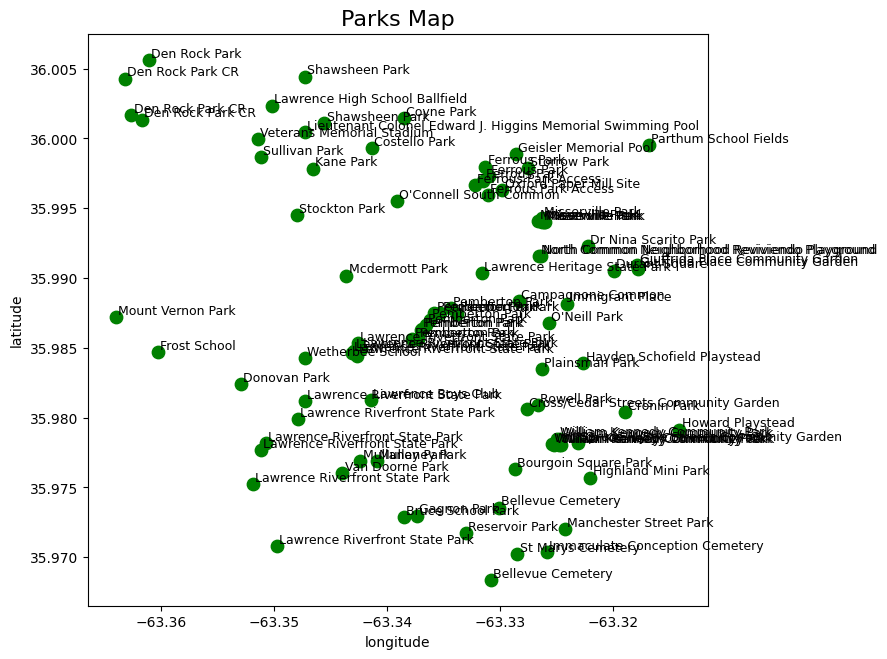

In [25]:
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
gdf.plot(ax=ax, color="green", markersize=80)
ax.set_title("Parks Map", fontsize=16)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")

# Optionally label points
for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf["NAME"]):
    ax.text(x + 0.0002, y + 0.0002, label, fontsize=9)

plt.show()

